# Figure 2b, 2d, 2e and Figure S2b — ExN sensory input and clustering

All four panels come from one source table, `../data/sensory_input_features/excitatory_neurons.csv`:
one row per reconstructed laminae I–II excitatory interneuron (n = 177), giving the number
of synapses it receives from each sensory subtype, the number of non-sensory (`N/A`)
synapses, and its final subtype label.

| Panel | Content | Needs |
| --- | --- | --- |
| **2b** | per-ExN heatmap: fraction of sensory input from each afferent subtype | the CSV only |
| **2e** | violin: fraction of *total* input that is sensory, by subtype | the CSV only |
| **2d** | UMAP of morphology + sensory-input features, HDBSCAN clusters | CSV + `../data/swc_skeletons/` |
| **S2b** | z-score heatmap of the features used for the embedding | CSV + SWCs |

**Everything runs offline — no CAVE access.**

### Labels

The CSV's `cell_type` column is a snapshot of the CAVE table
**`spinalcord_neuron_clusters_2`**, which holds the final expert-curated assignments. This
was verified against CAVE at materialization 669: of the 177 neurons, 156 are still present
under their recorded root ID and all 156 labels match; the remaining 21 have drifted root
IDs and, once resolved through the ChunkedGraph, **all 21 also match**. Using the CSV is
therefore equivalent to querying CAVE, and avoids silently dropping the 21 drifted neurons.
A cross-check cell is included below for anyone who wants to re-run the comparison.

The seven stored tags collapse to the six published subtypes — `v1` and `v2` are both
*Vertical* in this figure (they are separated in Figure S5):

| Tag | Subtype | n |
| --- | --- | --- |
| `v1` + `v2` | Vertical | 77 |
| `r` | Radial | 24 |
| `np_module` | C-HTMR/Heat module | 27 |
| `cltmr_module` | C-LTMR module | 24 |
| `adltmr_module` | Aδ-LTMR module | 15 |
| `noci_module` | Aδ-HTMR module | 10 |


In [12]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "svg.fonttype": "none",
    "font.size": 6,
})
CM = 1 / 2.54


In [13]:
from pathlib import Path

import numpy as np
import pandas as pd

CSV = Path("../data/sensory_input_features/excitatory_neurons.csv")

# Sensory subtype columns, in the published left-to-right order.
SUBTYPES = ["C-Cold", "Aδ-HTMR", "C-Heat", "C-HTMR",
            "C-HTMR-Non-peptidergic", "C-LTMR", "Aδ-LTMR", "Aβ-LTMR"]
LOW_CONF = "low_confidence_sensory"
NON_SENSORY = "N/A"

# Low-confidence sensory synapses count as sensory: they are shown as their own
# column in panel b and are included in the numerator of panel e. Excluding them
# does not reproduce the published statistics.
SENSORY_COLUMNS = SUBTYPES + [LOW_CONF]

DISPLAY = {
    "C-Heat": "Peptidergic C-fiber neurons",
    "C-HTMR": "C-HTMR/Heat (SST⁺)",
    "C-HTMR-Non-peptidergic": "C-HTMR/Heat (MrgprD⁺/A3⁺/B4⁺)",
    LOW_CONF: "Low confidence",
}

# stored tag -> published subtype
TAG_TO_GROUP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
    "r": "Radial",
    "v1": "Vertical",
    "v2": "Vertical",
}

# row order, top to bottom, in panel b
GROUP_ORDER_B = ["Aδ-HTMR module", "C-HTMR/Heat module", "C-LTMR module",
                 "Aδ-LTMR module", "Radial", "Vertical"]
# x order in panel e (ascending sensory fraction, as published)
GROUP_ORDER_E = ["Vertical", "Radial", "Aδ-LTMR module", "C-LTMR module",
                 "Aδ-HTMR module", "C-HTMR/Heat module"]

exn = pd.read_csv(CSV)
exn["group"] = exn.cell_type.str.strip().map(TAG_TO_GROUP)
if exn.group.isna().any():
    raise ValueError(f"unmapped tags: {sorted(exn.loc[exn.group.isna(), 'cell_type'].unique())}")

exn["n_sensory"] = exn[SENSORY_COLUMNS].sum(axis=1)
exn["n_total"] = exn["n_sensory"] + exn[NON_SENSORY]
exn["sensory_fraction"] = exn["n_sensory"] / exn["n_total"]

print(f"{len(exn)} ExNs")
print(exn.group.value_counts().reindex(GROUP_ORDER_B).to_string())


177 ExNs
group
Aδ-HTMR module        10
C-HTMR/Heat module    27
C-LTMR module         24
Aδ-LTMR module        15
Radial                24
Vertical              77


### Optional: re-verify the labels against CAVE

Skip this if you are working offline. It resolves any drifted root IDs through the
ChunkedGraph before comparing, so a mismatch here means a real relabelling rather than
segmentation drift.

In [14]:
def verify_labels_against_cave(exn, materialization=669):
    import caveclient

    client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr")
    client.version = materialization
    table = client.materialize.query_table("spinalcord_neuron_clusters_2")
    cave = dict(zip(table.pt_root_id.astype(int), table.tag.str.strip()))

    direct = drifted = mismatch = 0
    for rid, tag in zip(exn.neuron_id.astype(int), exn.cell_type.str.strip()):
        if rid in cave:
            direct += 1
        else:
            latest = client.chunkedgraph.is_latest_roots(np.array([rid], dtype=np.uint64))[0]
            rid = rid if latest else int(np.atleast_1d(
                client.chunkedgraph.suggest_latest_roots(int(rid)))[0])
            if rid not in cave:
                print(f"  {rid}: not in the CAVE table even after resolving")
                continue
            drifted += 1
        mismatch += (cave[rid] != tag)

    print(f"matched directly: {direct}, after resolving drifted IDs: {drifted}, "
          f"label mismatches: {mismatch}")


# verify_labels_against_cave(exn)


## Panel 2b — fraction of sensory input per ExN

One row per neuron, grouped into the six subtypes with red dashed separators; colour is
that afferent's share of the neuron's **sensory** synapses, so each row sums to 1.

Within a group, rows keep their order in the source table — the published panel does no
within-group sorting, it simply stacks the six blocks in the order above.

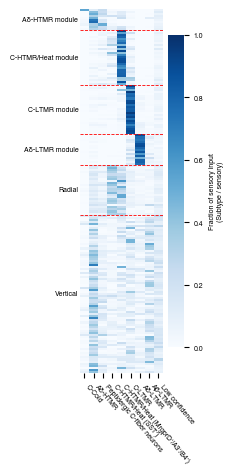

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

frac = exn[SENSORY_COLUMNS].div(exn.n_sensory, axis=0).fillna(0)
frac.columns = [DISPLAY.get(c, c) for c in SENSORY_COLUMNS]
frac["group"] = exn.group.to_numpy()

# Rows keep their order in the source table within each group -- the published
# panel does no within-group sorting, it simply concatenates the six blocks.
blocks = [frac[frac.group == g].drop(columns="group") for g in GROUP_ORDER_B]

ordered = pd.concat(blocks)
sizes = [len(b) for b in blocks]

fig = plt.figure(figsize=(4.3 * CM, 12 * CM))
grid = fig.add_gridspec(1, 2, width_ratios=[2.6, 10], wspace=0.0)

ax_lab = fig.add_subplot(grid[0, 0])
ax_lab.set_xlim(0, 1); ax_lab.set_ylim(0, len(ordered))
ax_lab.invert_yaxis(); ax_lab.axis("off")
start = 0
for g, n in zip(GROUP_ORDER_B, sizes):
    ax_lab.text(0.95, start + n / 2, g, va="center", ha="right", fontsize=5)
    start += n

ax = fig.add_subplot(grid[0, 1])
sns.heatmap(ordered, cmap="Blues", vmin=0, vmax=1, ax=ax,
            yticklabels=False, xticklabels=True, rasterized=True,
            cbar_kws={"label": "Fraction of sensory input"})
for b in np.cumsum(sizes)[:-1]:
    ax.hlines(y=b, xmin=0, xmax=ordered.shape[1], colors="red",
              linestyles="--", linewidth=0.6)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=5, rotation=-50, ha="left")
ax.set_ylabel("")
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=5)
cbar.set_label("Fraction of sensory input\n(Subtype / sensory)", fontsize=5)

fig.savefig("figure2b_exn_sensory_input_heatmap.svg", format="svg",
            bbox_inches="tight", dpi=600)
plt.show()


## Panel 2e — sensory as a fraction of total input

Per neuron, sensory synapses divided by all synapses (sensory + non-sensory). Vertical
cells stand out as receiving almost no direct sensory drive, consistent with their being
higher-order in the feedforward pathway.

Kruskal–Wallis followed by Dunn post hoc with Holm correction, as reported.

Kruskal-Wallis: H = 148.9, p = 2.342e-30


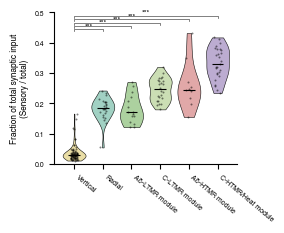


subtype                    n   median   vs Vertical
Vertical                  77    0.029             -
Radial                    24    0.185      2.97e-06
Aδ-LTMR module            15    0.170      0.000214
C-LTMR module             24    0.246      2.74e-13
Aδ-HTMR module            10    0.246      7.06e-07
C-HTMR/Heat module        27    0.328      1.81e-24


In [16]:
import scikit_posthocs as sp
from scipy.stats import kruskal

H, p = kruskal(*[exn.loc[exn.group == g, "sensory_fraction"].to_numpy()
                 for g in GROUP_ORDER_E])
print(f"Kruskal-Wallis: H = {H:.4g}, p = {p:.4g}")

dunn = sp.posthoc_dunn(exn, val_col="sensory_fraction", group_col="group",
                       p_adjust="holm")

PALETTE_E = {
    "Vertical": "#e8dca0", "Radial": "#9ccfc0", "Aδ-LTMR module": "#a8cf9a",
    "C-LTMR module": "#c9ddb0", "Aδ-HTMR module": "#e0a3a3",
    "C-HTMR/Heat module": "#b9a8cf",
}

fig, ax = plt.subplots(figsize=(6 * CM, 5 * CM))
data = [exn.loc[exn.group == g, "sensory_fraction"].to_numpy() for g in GROUP_ORDER_E]
parts = ax.violinplot(data, positions=np.arange(len(GROUP_ORDER_E)), widths=0.8,
                      showmeans=False, showmedians=True, showextrema=False)
for body, g in zip(parts["bodies"], GROUP_ORDER_E):
    body.set_facecolor(PALETTE_E[g]); body.set_edgecolor("black")
    body.set_linewidth(0.4); body.set_alpha(0.95)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(0.8)

rng = np.random.default_rng(0)
for i, vals in enumerate(data):
    ax.scatter(i + rng.uniform(-0.12, 0.12, len(vals)), vals,
               s=2, color="black", alpha=0.5, linewidths=0, zorder=3)

# Significance brackets: Vertical against every other subtype, stacked between the
# top of the data and the axis limit so they stay inside a 0-0.5 axis.
Y_MAX = 0.5
top = max(v.max() for v in data)
levels = np.linspace(top + 0.012, Y_MAX - 0.012, len(GROUP_ORDER_E) - 1)
for k, (g, yy) in enumerate(zip(GROUP_ORDER_E[1:], levels), start=1):
    pv = dunn.loc["Vertical", g]
    stars = "***" if pv < 1e-3 else "**" if pv < 1e-2 else "*" if pv < 0.05 else "n.s."
    ax.plot([0, 0, k, k], [yy - 0.006, yy, yy, yy - 0.006], lw=0.5, color="0.3")
    ax.text(k / 2, yy, stars, ha="center", va="bottom", fontsize=5)

ax.set_ylim(0, Y_MAX)
ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax.set_xticks(np.arange(len(GROUP_ORDER_E)))
ax.set_xticklabels(GROUP_ORDER_E, rotation=-40, ha="left", fontsize=5)
ax.set_ylabel("Fraction of total synaptic input\n(Sensory / total)", fontsize=6)
ax.tick_params(axis="y", labelsize=5)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.savefig("figure2e_sensory_fraction_violin.svg", format="svg", bbox_inches="tight")
plt.show()

print(f"\n{'subtype':24s}{'n':>4s}{'median':>9s}{'vs Vertical':>14s}")
for g in GROUP_ORDER_E:
    v = exn.loc[exn.group == g, "sensory_fraction"]
    pv = "-" if g == "Vertical" else f"{dunn.loc['Vertical', g]:.3g}"
    print(f"{g:24s}{len(v):4d}{v.median():9.3f}{pv:>14s}")


## Panels 2d and S2b — morphology + sensory-input embedding

From here the analysis adds **dendritic morphology features** extracted from the SWC
skeletons in `../data/swc_skeletons/` (one folder per stored tag), concatenates them with
the sensory-input features, z-scores every column, embeds with UMAP and clusters the 2D
embedding with HDBSCAN.

The cells below are the original working code, repointed at the repository's data. They
expect an `exn_tag` frame mapping root IDs to labels; the next cell builds it from the CSV
so no CAVE call is needed. Because the CSV's own root IDs are used, the historical →
current mapping inside the ported cell is an identity mapping and every one of the 177
neurons is retained.

In [17]:
from IPython.display import display   # the ported cells call display()

# ------------------------------------------------------------------
# Root IDs: CSV  ->  SWC file
# ------------------------------------------------------------------
# The sensory CSV and the SWC exports were made at different times, so 19 of the
# 177 neurons appear under different root IDs in the two. exn_swc_id_map.csv
# records the correspondence (built once with data_generation/build_exn_swc_id_map.ipynb;
# resolved through the ChunkedGraph and checked so that every neuron's SWC sits in the
# folder matching its label). Without it those 19 neurons get no morphology, are
# zero-filled, and the embedding and HDBSCAN clustering come out wrong.
ID_MAP = pd.read_csv("../data/sensory_input_features/exn_swc_id_map.csv")
CSV_TO_SWC = dict(zip(ID_MAP.csv_root_id.astype(np.int64),
                      ID_MAP.swc_root_id.astype(np.int64)))
print(f"{len(CSV_TO_SWC)} neurons; "
      f"{(ID_MAP.csv_root_id != ID_MAP.swc_root_id).sum()} have a different ID in the SWC set")

# The ported cells expect `exn_tag` (root ID -> label) and a `client` whose
# chunkedgraph maps a historical root ID to its current one. Both are served from
# the table above, so nothing here touches the network.
exn_tag = pd.DataFrame({
    "pt_root_id": ID_MAP.swc_root_id.astype(np.int64),
    "tag": ID_MAP.cell_type.str.strip(),
    "valid": True,
})

USE_CAVE = False   # True -> do the real ChunkedGraph lookup instead (needs a token)

if USE_CAVE:
    import caveclient
    client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr")
    client.version = 669
else:
    class _MappedChunkedGraph:
        """Resolves a historical root ID via the shipped CSV -> SWC table."""
        @staticmethod
        def get_latest_roots(ids):
            return np.array([CSV_TO_SWC.get(int(i), int(i))
                             for i in np.atleast_1d(np.asarray(ids))], dtype=np.int64)

    class _OfflineClient:
        chunkedgraph = _MappedChunkedGraph()

    client = _OfflineClient()
    print("using the shipped ID map (USE_CAVE = False)")


177 neurons; 19 have a different ID in the SWC set
using the shipped ID map (USE_CAVE = False)


In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ============================================================
# 1. Load the original sensory-input CSV
# ============================================================

CSV_PATH = Path(
    "../data/sensory_input_features/excitatory_neurons.csv"
)

# The first CSV column contains the historical neuron/root ID
sens = pd.read_csv(CSV_PATH, index_col=0)

sens.columns = [str(c).strip() for c in sens.columns]

# Normalize historical root IDs
sens.index = pd.to_numeric(
    sens.index,
    errors="raise"
).astype(np.int64)

sens.index.name = "old_root_id"

print(f"Loaded sensory CSV: {len(sens)} rows")
print(f"Unique historical root IDs: {sens.index.nunique()}")


# ============================================================
# 2. Prepare the current exn_tag dataframe
# ============================================================

exn_tag_current = exn_tag.copy()

# Keep valid rows.
# This handles values such as:
# True, "True", "true", "t", "1", and 1
if "valid" in exn_tag_current.columns:
    valid_mask = (
        exn_tag_current["valid"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "t", "1"])
    )

    exn_tag_current = exn_tag_current.loc[valid_mask].copy()

# Normalize current root IDs
exn_tag_current["pt_root_id"] = pd.to_numeric(
    exn_tag_current["pt_root_id"],
    errors="coerce"
).astype("Int64")

exn_tag_current = exn_tag_current.dropna(
    subset=["pt_root_id"]
).copy()

exn_tag_current["pt_root_id"] = (
    exn_tag_current["pt_root_id"].astype(np.int64)
)

current_roots = set(
    exn_tag_current["pt_root_id"].tolist()
)

print(f"Valid exn_tag rows: {len(exn_tag_current)}")
print(f"Unique current ExN root IDs: {len(current_roots)}")

if len(current_roots) == 0:
    raise ValueError(
        "No current root IDs remained in exn_tag. "
        "Check exn_tag['valid'] and exn_tag['pt_root_id']."
    )


# ============================================================
# 3. Map historical CSV roots to latest CAVE roots
# ============================================================

mapping_rows = []

for old_root in tqdm(
    sens.index.unique(),
    desc="Updating root IDs"
):
    old_root = int(old_root)

    try:
        latest_roots = client.chunkedgraph.get_latest_roots(
            [old_root]
        )

        latest_roots = sorted({
            int(root)
            for root in np.asarray(latest_roots).reshape(-1)
            if pd.notna(root) and int(root) != 0
        })

        # Retain current descendants that appear in exn_tag
        exn_matches = [
            root
            for root in latest_roots
            if root in current_roots
        ]

        if len(exn_matches) == 1:
            current_root = exn_matches[0]
            status = "matched"

        elif len(exn_matches) == 0:
            current_root = pd.NA
            status = "no_exn_tag_match"

        else:
            current_root = pd.NA
            status = "ambiguous_multiple_matches"

        error = None

    except Exception as exc:
        latest_roots = []
        exn_matches = []
        current_root = pd.NA
        status = "query_error"
        error = str(exc)

    mapping_rows.append({
        "old_root_id": old_root,
        "current_root_id": current_root,
        "latest_root_candidates": latest_roots,
        "exn_tag_candidates": exn_matches,
        "match_status": status,
        "error": error,
    })


root_mapping = pd.DataFrame(mapping_rows)

root_mapping["old_root_id"] = (
    root_mapping["old_root_id"].astype(np.int64)
)

root_mapping["current_root_id"] = pd.to_numeric(
    root_mapping["current_root_id"],
    errors="coerce"
).astype("Int64")


# ============================================================
# 4. Attach current IDs to the sensory dataframe
# ============================================================

# Preserve the original historical ID as a normal column
sens_aligned = (
    sens.reset_index()
    .merge(
        root_mapping,
        on="old_root_id",
        how="left",
        validate="many_to_one",
    )
)

# Add current ExN tag
exn_metadata = (
    exn_tag_current[
        ["pt_root_id", "tag"]
    ]
    .drop_duplicates(subset="pt_root_id")
    .rename(columns={
        "pt_root_id": "current_root_id",
        "tag": "current_exn_tag",
    })
)

sens_aligned = sens_aligned.merge(
    exn_metadata,
    on="current_root_id",
    how="left",
    validate="many_to_one",
)


# ============================================================
# 5. Report the matching result
# ============================================================

print("\nMatch status:")
print(
    sens_aligned["match_status"]
    .value_counts(dropna=False)
)

matched_mask = sens_aligned["match_status"].eq("matched")

print(
    f"\nMatched rows: "
    f"{matched_mask.sum()} / {len(sens_aligned)}"
)

changed_mask = (
    matched_mask
    & (
        sens_aligned["old_root_id"]
        != sens_aligned["current_root_id"]
    )
)

print(f"Root IDs changed: {changed_mask.sum()}")

display(
    sens_aligned[
        [
            "old_root_id",
            "current_root_id",
            "current_exn_tag",
            "match_status",
        ]
    ].head(20)
)


# ============================================================
# 6. Create a matched-only dataframe for later analysis
# ============================================================

sens_matched = sens_aligned.loc[
    matched_mask
].copy()

sens_matched["current_root_id"] = (
    sens_matched["current_root_id"].astype(np.int64)
)

# Use current root ID as the index for later SWC matching
sens_matched = sens_matched.set_index(
    "current_root_id",
    drop=True,
)

sens_matched.index.name = "root_id"

print(
    f"\nsens_matched contains "
    f"{len(sens_matched)} successfully aligned rows."
)

display(
    sens_matched[
        [
            "old_root_id",
            "current_exn_tag",
            "match_status",
        ]
    ].head()
)

Loaded sensory CSV: 177 rows
Unique historical root IDs: 177
Valid exn_tag rows: 177
Unique current ExN root IDs: 177


Updating root IDs: 100%|██████████| 177/177 [00:00<00:00, 80677.22it/s]


Match status:
match_status
matched    177
Name: count, dtype: int64

Matched rows: 177 / 177
Root IDs changed: 19


,old_root_id,current_root_id,current_exn_tag,match_status
0,720575940905042134,720575940905042134,v2,matched
1,720575940893395733,720575940893395733,np_module,matched
2,720575940916016480,720575940916016480,np_module,matched
3,720575940890107704,720575940890107704,v2,matched
4,720575940905061686,720575940905061686,np_module,matched
5,720575940917975893,720575940917975893,v1,matched
6,720575940859648663,720575940859648663,v1,matched
7,720575940891181902,720575940891181902,cltmr_module,matched
8,720575940878957108,720575940878957108,v1,matched
9,720575940889238903,720575940889238903,cltmr_module,matched



sens_matched contains 177 successfully aligned rows.


,old_root_id,current_exn_tag,match_status
root_id,,,
720575940905042134,720575940905042134,v2,matched
720575940893395733,720575940893395733,np_module,matched
720575940916016480,720575940916016480,np_module,matched
720575940890107704,720575940890107704,v2,matched
720575940905061686,720575940905061686,np_module,matched


In [19]:
# ============================================================
# Seven-class analysis using:
#   1. Dendritic morphology from corrected SWCs
#   2. Sensory-input features from sens_matched
#
# Required existing dataframe:
#   sens_matched
#
# sens_matched index:
#   current root ID
#
# Classes:
#   adltmr_module
#   cltmr_module
#   noci_module
#   np_module
#   r
#   v1
#   v2
# ============================================================

from pathlib import Path
from typing import Dict, Tuple, List, Optional
from collections import Counter

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


# ============================================================
# 0. Settings
# ============================================================

VERBOSE = True

SWC_BASE = Path(
    "../data/swc_skeletons"
)

CLASS_ORDER = [
    "adltmr_module",
    "cltmr_module",
    "noci_module",
    "np_module",
    "r",
    "v1",
    "v2",
]

# Optional Sholl analysis
INCLUDE_SHOLL = False
SHOLL_STEP_UM = 30.0
SHOLL_FULL = False
SHOLL_PREFIX = "sholl_dend_"

# Sensory feature blocks
SENS_INCLUDE_RAW = False
SENS_INCLUDE_FRACTION = True
SENS_INCLUDE_LOG1P = True
SENS_INCLUDE_CNS_FRAC = True

desired_cols = [
    "Aδ-HTMR",
    "C-Cold",
    "C-HTMR",
    "C-HTMR-Non-peptidergic",
    "C-Heat",
    "N/A",
    "Aβ-LTMR",
    "Aδ-LTMR",
    "C-LTMR",
    "low_confidence_sensory",
]

warnings.filterwarnings(
    "ignore",
    message=r".*'multi_class' was deprecated.*",
    category=FutureWarning,
)


# ============================================================
# 1. Validate and prepare sens_matched
# ============================================================

if "sens_matched" not in globals():
    raise NameError(
        "sens_matched does not exist. "
        "Run the root-ID remapping block first."
    )

sens7 = sens_matched.copy()

# Ensure current root IDs are integer-valued
sens7.index = pd.to_numeric(
    sens7.index,
    errors="raise",
).astype(np.int64)

sens7.index.name = "root_id"

# Use the current annotation from exn_tag
if "current_exn_tag" not in sens7.columns:
    raise ValueError(
        "sens_matched must contain the column 'current_exn_tag'."
    )

sens7["current_exn_tag"] = (
    sens7["current_exn_tag"]
    .astype(str)
    .str.strip()
)

# Keep only requested seven classes
sens7 = sens7.loc[
    sens7["current_exn_tag"].isin(CLASS_ORDER)
].copy()

# Check required sensory columns
missing_columns = sorted(
    set(desired_cols) - set(sens7.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing sensory-input columns: {missing_columns}"
    )

print(f"Sensory rows in requested classes: {len(sens7)}")

print("\nClass counts in sensory dataframe:")
print(
    sens7["current_exn_tag"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)


# ============================================================
# 2. General SWC helpers
# ============================================================

def load_swc_df(path: str) -> pd.DataFrame:
    columns = [
        "n",
        "type",
        "x",
        "y",
        "z",
        "radius",
        "parent",
    ]

    return pd.read_csv(
        path,
        comment="#",
        sep=r"\s+",
        engine="python",
        header=None,
        names=columns,
        dtype={
            "n": int,
            "type": int,
            "x": float,
            "y": float,
            "z": float,
            "radius": float,
            "parent": int,
        },
    )


def detect_units_from_header(
    path: str,
) -> Optional[str]:

    try:
        with open(path, "r") as file:
            for _ in range(80):
                line = file.readline()

                if not line or not line.startswith("#"):
                    break

                match = re.search(
                    r"#\s*Units[:=]\s*([a-zA-Z]+)",
                    line,
                )

                if match:
                    return match.group(1).strip().lower()

    except Exception:
        pass

    return None


def build_parent_index(
    df: pd.DataFrame,
) -> Tuple[Dict[int, int], np.ndarray]:

    id_to_index = {
        int(node_id): index
        for index, node_id in enumerate(df["n"].tolist())
    }

    parent_ids = df["parent"].to_numpy()

    parent_index = np.array(
        [
            id_to_index[parent]
            if parent in id_to_index
            else -1
            for parent in parent_ids
        ],
        dtype=int,
    )

    return id_to_index, parent_index


def segment_lengths(
    df: pd.DataFrame,
    parent_index: np.ndarray,
) -> np.ndarray:

    xyz = df[["x", "y", "z"]].to_numpy(float)

    lengths = np.zeros(
        len(df),
        dtype=float,
    )

    for index, parent in enumerate(parent_index):
        if parent >= 0:
            delta = xyz[index] - xyz[parent]
            lengths[index] = float(
                np.linalg.norm(delta)
            )

    return lengths


def degrees(
    parent_index: np.ndarray,
) -> np.ndarray:

    degree = np.zeros(
        len(parent_index),
        dtype=int,
    )

    for index, parent in enumerate(parent_index):
        if parent >= 0:
            degree[index] += 1
            degree[parent] += 1

    return degree


def adjacency(
    parent_index: np.ndarray,
) -> List[List[int]]:

    graph = [
        []
        for _ in range(len(parent_index))
    ]

    for index, parent in enumerate(parent_index):
        if parent >= 0:
            graph[index].append(parent)
            graph[parent].append(index)

    return graph


def guess_soma_index(
    df: pd.DataFrame,
    parent_index: np.ndarray,
) -> int:

    roots = np.where(
        parent_index == -1
    )[0]

    if roots.size:
        return int(roots[0])

    soma_nodes = np.where(
        df["type"].to_numpy(int) == 1
    )[0]

    if soma_nodes.size:
        return int(soma_nodes[0])

    return 0


def choose_root_for_dendrites(
    df: pd.DataFrame,
    parent_index: np.ndarray,
) -> int:
    """
    For SWCs with multiple disconnected components,
    choose the component containing the largest number
    of dendritic nodes.
    """

    roots = np.where(
        parent_index == -1
    )[0]

    if roots.size == 0:
        return guess_soma_index(
            df,
            parent_index,
        )

    node_types = df["type"].to_numpy(int)
    graph = adjacency(parent_index)

    best_root = int(roots[0])
    best_dendrite_count = -1

    for root in roots:
        root = int(root)

        stack = [root]
        visited = {root}
        dendrite_count = 0

        while stack:
            node = stack.pop()

            if node_types[node] == 3:
                dendrite_count += 1

            for neighbor in graph[node]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    stack.append(neighbor)

        if dendrite_count > best_dendrite_count:
            best_dendrite_count = dendrite_count
            best_root = root

    return best_root


def path_lengths_from(
    root: int,
    segment_length: np.ndarray,
    parent_index: np.ndarray,
) -> np.ndarray:

    graph = adjacency(parent_index)

    distances = np.full(
        len(segment_length),
        np.nan,
        dtype=float,
    )

    distances[root] = 0.0

    stack = [root]

    visited = np.zeros(
        len(segment_length),
        dtype=bool,
    )

    visited[root] = True

    while stack:
        node = stack.pop()

        for neighbor in graph[node]:
            if visited[neighbor]:
                continue

            if parent_index[neighbor] == node:
                edge_length = segment_length[neighbor]

            elif parent_index[node] == neighbor:
                edge_length = segment_length[node]

            else:
                edge_length = 0.0

            distances[neighbor] = (
                distances[node] + edge_length
            )

            visited[neighbor] = True
            stack.append(neighbor)

    return distances


def trapezoid_area(
    y: np.ndarray,
    x: np.ndarray,
) -> float:

    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)

    if y.size < 2:
        return 0.0

    if hasattr(np, "trapezoid"):
        return float(
            np.trapezoid(y, x)
        )

    delta_x = np.diff(x)
    midpoint_y = 0.5 * (
        y[1:] + y[:-1]
    )

    return float(
        np.sum(midpoint_y * delta_x)
    )


# ============================================================
# 3. Optional dendritic Sholl analysis
# ============================================================

def sholl_counts_dendrite(
    xyz_um: np.ndarray,
    node_types: np.ndarray,
    parent_index: np.ndarray,
    soma_xyz: np.ndarray,
    step_um: float,
    maximum_radius_um: Optional[float] = None,
) -> Tuple[np.ndarray, np.ndarray]:

    if maximum_radius_um is None:
        dendrite_mask = node_types == 3

        if not np.any(dendrite_mask):
            return np.array([]), np.array([])

        node_radii = np.linalg.norm(
            xyz_um[dendrite_mask]
            - soma_xyz[None, :],
            axis=1,
        )

        maximum_radius_um = float(
            np.nanmax(node_radii)
        )

    if (
        not np.isfinite(maximum_radius_um)
        or maximum_radius_um <= 0
    ):
        return np.array([]), np.array([])

    radii = np.arange(
        step_um,
        maximum_radius_um + 1e-9,
        step_um,
        dtype=float,
    )

    counts = np.zeros_like(
        radii,
        dtype=int,
    )

    for index, parent in enumerate(parent_index):
        if parent < 0:
            continue

        if node_types[index] != 3:
            continue

        if node_types[parent] == 2:
            continue

        parent_distance = float(
            np.linalg.norm(
                xyz_um[parent] - soma_xyz
            )
        )

        child_distance = float(
            np.linalg.norm(
                xyz_um[index] - soma_xyz
            )
        )

        if parent_distance == child_distance:
            continue

        lower = min(
            parent_distance,
            child_distance,
        )

        upper = max(
            parent_distance,
            child_distance,
        )

        crossings = (
            (radii > lower)
            & (radii <= upper)
        )

        counts[crossings] += 1

    return radii, counts


# ============================================================
# 4. Extract dendritic morphology features
# ============================================================

def extract_dendrite_features(
    path: str,
    include_sholl: bool = False,
    sholl_step_um: float = 30.0,
    sholl_full: bool = False,
    sholl_prefix: str = "sholl_dend_",
) -> pd.Series:

    df = load_swc_df(path)

    units = (
        detect_units_from_header(path)
        or "nm"
    )

    conversion_to_um = (
        1e-3
        if units.lower() == "nm"
        else 1.0
    )

    _, parent_index = build_parent_index(df)

    segment_length_um = (
        segment_lengths(
            df,
            parent_index,
        )
        * conversion_to_um
    )

    degree = degrees(parent_index)

    node_types = df["type"].to_numpy(int)

    xyz_um = (
        df[["x", "y", "z"]]
        .to_numpy(float)
        * conversion_to_um
    )

    axon_mask = node_types == 2
    dendrite_mask = node_types == 3

    axon_length_um = float(
        segment_length_um[axon_mask].sum()
    )

    has_axon = axon_length_um > 0

    dendrite_segment_lengths = (
        segment_length_um[dendrite_mask]
    )

    dendrite_length_um = float(
        dendrite_segment_lengths.sum()
    )

    tip_mask = degree == 1
    branch_mask = degree >= 3

    dendrite_tips = int(
        np.count_nonzero(
            tip_mask & dendrite_mask
        )
    )

    dendrite_branches = int(
        np.count_nonzero(
            branch_mask & dendrite_mask
        )
    )

    soma_index = choose_root_for_dendrites(
        df,
        parent_index,
    )

    soma_xyz = xyz_um[soma_index]
    soma_y_um = float(soma_xyz[1])

    path_distance_um = path_lengths_from(
        soma_index,
        segment_length_um,
        parent_index,
    )

    dendrite_tip_indices = np.where(
        tip_mask & dendrite_mask
    )[0]

    if dendrite_tip_indices.size:
        tip_distances = (
            path_distance_um[dendrite_tip_indices]
        )

        tip_distances = tip_distances[
            np.isfinite(tip_distances)
        ]

        maximum_path_um = (
            float(tip_distances.max())
            if tip_distances.size
            else 0.0
        )

    else:
        maximum_path_um = 0.0

    mean_segment_length_um = (
        float(dendrite_segment_lengths.mean())
        if dendrite_segment_lengths.size
        else 0.0
    )

    branches_per_100_um = (
        dendrite_branches
        / dendrite_length_um
        * 100.0
        if dendrite_length_um > 0
        else 0.0
    )

    tips_per_100_um = (
        dendrite_tips
        / dendrite_length_um
        * 100.0
        if dendrite_length_um > 0
        else 0.0
    )

    if np.any(dendrite_mask):
        dendrite_xyz = xyz_um[dendrite_mask]

        x_span_um = float(
            dendrite_xyz[:, 0].max()
            - dendrite_xyz[:, 0].min()
        )

        y_span_um = float(
            dendrite_xyz[:, 1].max()
            - dendrite_xyz[:, 1].min()
        )

        z_span_um = float(
            dendrite_xyz[:, 2].max()
            - dendrite_xyz[:, 2].min()
        )

        bounding_box_volume_um3 = (
            x_span_um
            * y_span_um
            * z_span_um
        )

    else:
        x_span_um = 0.0
        y_span_um = 0.0
        z_span_um = 0.0
        bounding_box_volume_um3 = 0.0

    # Dendritic directionality
    edge_indices = np.where(
        dendrite_mask
        & (parent_index >= 0)
    )[0]

    unit_vectors = []

    for index in edge_indices:
        parent = parent_index[index]

        vector = (
            xyz_um[index]
            - xyz_um[parent]
        )

        length = np.linalg.norm(vector)

        if length > 0:
            unit_vectors.append(
                vector / length
            )

    if unit_vectors:
        mean_vector = np.mean(
            np.stack(unit_vectors, axis=0),
            axis=0,
        )

        dendritic_directionality = float(
            np.linalg.norm(mean_vector)
        )

    else:
        dendritic_directionality = 0.0

    # Path-length / straight-distance ratio
    if dendrite_tip_indices.size:
        tip_distances_all = (
            path_distance_um[dendrite_tip_indices]
        )

        finite_mask = np.isfinite(
            tip_distances_all
        )

        if np.any(finite_mask):
            finite_tip_indices = (
                dendrite_tip_indices[finite_mask]
            )

            farthest_tip_index = int(
                finite_tip_indices[
                    np.argmax(
                        tip_distances_all[finite_mask]
                    )
                ]
            )

            straight_distance_um = float(
                np.linalg.norm(
                    xyz_um[farthest_tip_index]
                    - soma_xyz
                )
            )

        else:
            straight_distance_um = 0.0

    else:
        straight_distance_um = 0.0

    path_vs_straight = (
        maximum_path_um
        / straight_distance_um
        if straight_distance_um > 0
        else 0.0
    )

    output = {
        "has_axon": bool(has_axon),
        "axon_len_um": axon_length_um,
        "dend_len_um": dendrite_length_um,
        "tips_dend": dendrite_tips,
        "branch_dend": dendrite_branches,
        "branch_per_100um": branches_per_100_um,
        "tips_per_100um": tips_per_100_um,
        "mean_seglen_dend": mean_segment_length_um,
        "max_path_dend_um": maximum_path_um,
        "x_span_um": x_span_um,
        "y_span_um": y_span_um,
        "z_span_um": z_span_um,
        "bbox_vol_um3": bounding_box_volume_um3,
        "directionality_dend": dendritic_directionality,
        "path_vs_straight": path_vs_straight,
        "soma_y_um": soma_y_um,
    }

    if include_sholl:
        if np.any(dendrite_mask):
            dendrite_radii = np.linalg.norm(
                xyz_um[dendrite_mask]
                - soma_xyz[None, :],
                axis=1,
            )

            maximum_radius = (
                float(np.nanmax(dendrite_radii))
                if np.isfinite(dendrite_radii).any()
                else 0.0
            )

        else:
            maximum_radius = 0.0

        radii, counts = sholl_counts_dendrite(
            xyz_um=xyz_um,
            node_types=node_types,
            parent_index=parent_index,
            soma_xyz=soma_xyz,
            step_um=sholl_step_um,
            maximum_radius_um=maximum_radius,
        )

        if radii.size:
            peak_index = int(
                np.argmax(counts)
            )

            output[
                "sholl_dend_peak_count"
            ] = int(counts[peak_index])

            output[
                "sholl_dend_peak_radius_um"
            ] = float(radii[peak_index])

            output[
                "sholl_dend_mean"
            ] = float(np.mean(counts))

            output[
                "sholl_dend_area"
            ] = trapezoid_area(
                counts.astype(float),
                radii,
            )

            if radii.size >= 2:
                slope, intercept = np.polyfit(
                    radii,
                    counts.astype(float),
                    1,
                )
            else:
                slope = 0.0
                intercept = float(counts[0])

            output[
                "sholl_dend_slope_per_um"
            ] = float(slope)

            output[
                "sholl_dend_intercept"
            ] = float(intercept)

            if sholl_full:
                for radius, count in zip(
                    radii,
                    counts,
                ):
                    radius_label = int(
                        np.round(radius)
                    )

                    output[
                        f"{sholl_prefix}N_r{radius_label}um"
                    ] = int(count)

        else:
            output.update({
                "sholl_dend_peak_count": 0,
                "sholl_dend_peak_radius_um": 0.0,
                "sholl_dend_mean": 0.0,
                "sholl_dend_area": 0.0,
                "sholl_dend_slope_per_um": 0.0,
                "sholl_dend_intercept": 0.0,
            })

    return pd.Series(output)


# ============================================================
# 5. Extract morphology from corrected SWCs
# ============================================================

morphology_rows = []
morphology_ids = []
morphology_labels = []
errors = []

for class_name in CLASS_ORDER:
    class_folder = SWC_BASE / class_name

    if not class_folder.exists():
        print(
            f"[WARN] Folder does not exist: "
            f"{class_folder}"
        )
        continue

    for swc_path in class_folder.glob("*.swc"):
        try:
            root_id = int(swc_path.stem)

            features = extract_dendrite_features(
                str(swc_path),
                include_sholl=INCLUDE_SHOLL,
                sholl_step_um=SHOLL_STEP_UM,
                sholl_full=SHOLL_FULL,
                sholl_prefix=SHOLL_PREFIX,
            )

            morphology_rows.append(features)
            morphology_ids.append(root_id)
            morphology_labels.append(class_name)

        except Exception as exception:
            errors.append({
                "swc_path": str(swc_path),
                "error": str(exception),
            })

if errors:
    print(
        f"\n[WARN] Failed to process "
        f"{len(errors)} SWCs."
    )

    display(
        pd.DataFrame(errors).head(20)
    )

if len(morphology_rows) == 0:
    raise ValueError(
        "No SWC morphology was successfully loaded."
    )

morph_all = pd.DataFrame(
    morphology_rows,
    index=pd.Index(
        morphology_ids,
        name="root_id",
        dtype=np.int64,
    ),
)

morph_all["swc_folder_label"] = (
    morphology_labels
)

print(
    f"\nSuccessfully extracted morphology "
    f"from {len(morph_all)} SWCs."
)


# ============================================================
# 6. Check whether SWC folder labels agree with exn_tag
# ============================================================

label_check = (
    morph_all[["swc_folder_label"]]
    .join(
        sens7[["current_exn_tag"]],
        how="inner",
    )
)

label_check["labels_agree"] = (
    label_check["swc_folder_label"]
    == label_check["current_exn_tag"]
)

print(
    "\nSWC folder label versus current exn_tag:"
)

print(
    label_check["labels_agree"]
    .value_counts(dropna=False)
)

if (~label_check["labels_agree"]).any():
    print("\nMismatched labels:")

    display(
        label_check.loc[
            ~label_check["labels_agree"]
        ]
    )


# ============================================================
# 7. Construct dendritic morphology feature matrix
# ============================================================

# Same filter used in the previous analysis:
# require a detected axon and nonzero dendritic length
keep_morphology = (
    morph_all["dend_len_um"] > 0
)

X_morph = (
    morph_all.loc[keep_morphology]
    .drop(
        columns=[
            "has_axon",
            "axon_len_um",
            "swc_folder_label",
        ]
    )
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .fillna(0.0)
)

print(
    f"\nMorphology rows after filtering: "
    f"{len(X_morph)}"
)


# ============================================================
# 8. Align morphology and sensory-input data
# ============================================================

common_root_ids = (
    X_morph.index
    .intersection(sens7.index)
)

X_morph = X_morph.loc[
    common_root_ids
].copy()

sens_common = sens7.loc[
    common_root_ids
].copy()

y7 = (
    sens_common["current_exn_tag"]
    .astype(str)
)

counts = (
    sens_common[desired_cols]
    .astype(float)
    .fillna(0.0)
)

print(
    f"\nAligned neurons with both morphology "
    f"and sensory input: {len(common_root_ids)}"
)

print("\nAligned class counts:")
print(
    y7.value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
)

# Show neurons lacking a matching usable SWC
missing_morphology_ids = (
    sens7.index
    .difference(X_morph.index)
)

print(
    f"\nSensory neurons without a usable "
    f"matching morphology: "
    f"{len(missing_morphology_ids)}"
)

if len(missing_morphology_ids):
    display(
        sens7.loc[
            sens7.index.intersection(
                missing_morphology_ids
            ),
            [
                "old_root_id",
                "current_exn_tag",
            ],
        ]
    )


# ============================================================
# 9. Build sensory-input features
# ============================================================

sensory_parts = []

# Raw counts
if SENS_INCLUDE_RAW:
    sensory_counts = counts.copy()

    sensory_counts.columns = [
        f"sens_count__{column}"
        for column in sensory_counts.columns
    ]

    sensory_parts.append(
        sensory_counts
    )

# Total counted input
row_sums = (
    counts.sum(axis=1)
    .replace(0.0, np.nan)
)

# Fractions
if SENS_INCLUDE_FRACTION:
    sensory_fractions = (
        counts.div(
            row_sums,
            axis=0,
        )
        .fillna(0.0)
    )

    sensory_fractions.columns = [
        f"sens_frac__{column}"
        for column in sensory_fractions.columns
    ]

    # Avoid duplicating N/A fraction
    if (
        SENS_INCLUDE_CNS_FRAC
        and "sens_frac__N/A"
        in sensory_fractions.columns
    ):
        sensory_fractions = (
            sensory_fractions.drop(
                columns=["sens_frac__N/A"]
            )
        )

    sensory_parts.append(
        sensory_fractions
    )

# log1p synapse counts
if SENS_INCLUDE_LOG1P:
    sensory_log_counts = np.log1p(
        counts
    )

    sensory_log_counts.columns = [
        f"sens_log1p__{column}"
        for column in sensory_log_counts.columns
    ]

    sensory_parts.append(
        sensory_log_counts
    )

# N/A fraction
if SENS_INCLUDE_CNS_FRAC:
    cns_fraction = (
        counts["N/A"]
        .div(row_sums)
        .fillna(0.0)
        .rename("cns_fraction")
        .to_frame()
    )

    sensory_parts.append(
        cns_fraction
    )

X_sens = (
    pd.concat(
        sensory_parts,
        axis=1,
    )
    if sensory_parts
    else pd.DataFrame(
        index=common_root_ids
    )
)


# ============================================================
# 10. Combine morphology and sensory features
#     with optional manual feature removal
# ============================================================

# Manually list any features you want to exclude.
# Leave this empty [] to use all features.
FEATURES_TO_DROP = [
#    "bbox_vol_um3",
    "path_vs_straight",
    # "x_span_um",
    # "directionality_dend",
#    "sens_frac__C-HTMR",
 #   "sens_log1p__low_confidence_sensory"
]

# First construct the complete combined feature matrix
X_all = (
    pd.concat(
        [
            X_morph,
            X_sens,
        ],
        axis=1,
    )
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .fillna(0.0)
)

# Check whether any requested feature names do not exist
missing_drop_features = [
    feature
    for feature in FEATURES_TO_DROP
    if feature not in X_all.columns
]

if missing_drop_features:
    print(
        "\n[WARNING] These requested features were not found "
        "and therefore could not be removed:"
    )
    for feature in missing_drop_features:
        print(f"  - {feature}")

# Keep only feature names that actually exist
features_removed = [
    feature
    for feature in FEATURES_TO_DROP
    if feature in X_all.columns
]

# Create the final feature matrix
X = X_all.drop(
    columns=features_removed,
    errors="ignore",
).copy()

print("\nFeature selection summary")
print("-------------------------")
print(f"Neurons: {X.shape[0]}")
print(f"Original features: {X_all.shape[1]}")
print(f"Features removed: {len(features_removed)}")
print(f"Features retained: {X.shape[1]}")

if features_removed:
    print("\nRemoved features:")
    for feature in features_removed:
        print(f"  - {feature}")
else:
    print("\nNo features were removed.")

if len(X) == 0:
    raise ValueError(
        "No neurons remain after morphology/sensory alignment."
    )

if X.shape[1] == 0:
    raise ValueError(
        "No features remain after manual feature removal."
    )

unexpected_labels = (
    set(y7.unique())
    - set(CLASS_ORDER)
)

if unexpected_labels:
    raise ValueError(
        f"Unexpected labels found in y7: "
        f"{sorted(unexpected_labels)}"
    )


# ============================================================
# Evaluate both 7-class and merged 6-class classification
# ============================================================

from collections import Counter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
)


def safe_cv_splits(labels, max_splits=5):
    return max(
        2,
        min(
            max_splits,
            min(Counter(labels).values())
        ),
    )


def evaluate(X, y, title):

    n_splits = safe_cv_splits(y)

    clf = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "lr",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                solver="lbfgs",
                random_state=0,
            ),
        ),
    ])

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    pred = cross_val_predict(
        clf,
        X,
        y,
        cv=cv,
    )

    acc = accuracy_score(y, pred)

    f1 = f1_score(
        y,
        pred,
        average="macro",
    )

    print(f"\n=== {title} ===")
    print(f"Accuracy: {acc:.3f}   Macro F1: {f1:.3f}")

    return {
        "accuracy": acc,
        "macro_f1": f1,
    }


# ------------------------------------------------------------
# Original 7-class labels
# ------------------------------------------------------------

results7 = evaluate(
    X,
    y7,
    "7-class (original cell_type labels)",
)

# ------------------------------------------------------------
# Merge v1 and v2 into one Vertical class
# ------------------------------------------------------------

y6 = y7.replace({
    "v1": "vertical",
    "v2": "vertical",
})

results6 = evaluate(
    X,
    y6,
    "6-class (Vertical merged)",
)

Sensory rows in requested classes: 177

Class counts in sensory dataframe:
current_exn_tag
adltmr_module    15
cltmr_module     24
noci_module      10
np_module        27
r                24
v1               41
v2               36
Name: count, dtype: int64

Successfully extracted morphology from 177 SWCs.

SWC folder label versus current exn_tag:
labels_agree
True    177
Name: count, dtype: int64

Morphology rows after filtering: 177

Aligned neurons with both morphology and sensory input: 177

Aligned class counts:
current_exn_tag
adltmr_module    15
cltmr_module     24
noci_module      10
np_module        27
r                24
v1               41
v2               36
Name: count, dtype: int64

Sensory neurons without a usable matching morphology: 0

Feature selection summary
-------------------------
Neurons: 177
Original features: 34
Features removed: 1
Features retained: 33

Removed features:
  - path_vs_straight

=== 7-class (original cell_type labels) ===
Accuracy: 0.870   Macro 

umap-learn: 0.5.9.post2
Neurons in UMAP: 177

Original class counts:
current_exn_tag
v1               41
v2               36
np_module        27
cltmr_module     24
r                24
adltmr_module    15
noci_module      10
Name: count, dtype: int64

Embedding shape: (177, 2)

Displayed group counts:
current_exn_tag
Aδ-LTMR module        15
C-LTMR module         24
Aδ-HTMR module        10
C-HTMR/Heat module    27
Radial                24
Vertical              77
Name: count, dtype: int64


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


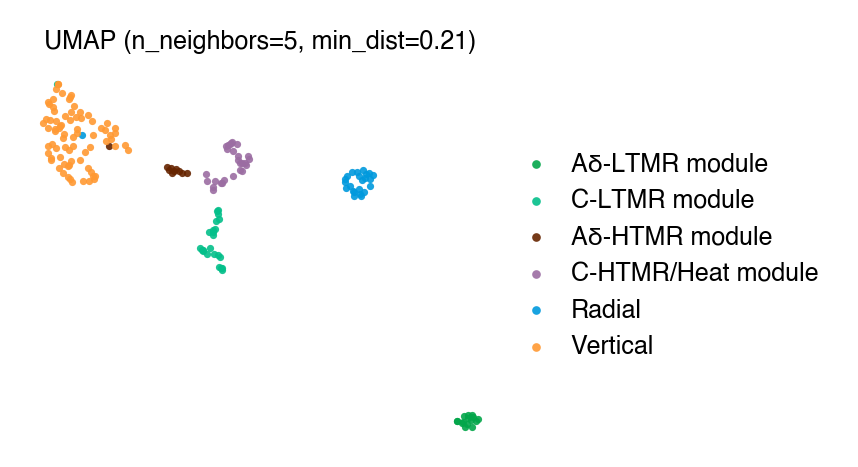

In [20]:
# ============================================================
# UMAP on combined morphology + sensory-input features
# v1 and v2 are plotted together as one "Vertical" group
# ============================================================

from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import umap
from umap import UMAP

print("umap-learn:", getattr(umap, "__version__", "unknown"))


# ------------------------------------------------------------
# Global plotting style
# ------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
})


# ------------------------------------------------------------
# UMAP parameters
# ------------------------------------------------------------

N_NEIGHBORS = 5
MIN_DIST = 0.21
RANDOM_STATE = 42

FIG_SIZE_CM = (7.0, 4.0)

POINT_SIZE = 3
POINT_ALPHA = 0.9

SAVE_PATH = None
# Example:
# SAVE_PATH = (
#     "figure2d_umap_combined.svg"
# )


# ------------------------------------------------------------
# Validate and align labels
# ------------------------------------------------------------

if not isinstance(X, pd.DataFrame):
    raise TypeError("X must be a pandas DataFrame.")

if not isinstance(y7, pd.Series):
    raise TypeError("y7 must be a pandas Series.")

y7_plot = y7.loc[X.index].copy()

expected_labels = {
    "adltmr_module",
    "cltmr_module",
    "noci_module",
    "np_module",
    "r",
    "v1",
    "v2",
}

unexpected_labels = sorted(
    set(y7_plot.unique()) - expected_labels
)

if unexpected_labels:
    raise ValueError(
        f"Unexpected labels found in y7: {unexpected_labels}"
    )

print("Neurons in UMAP:", len(X))

print("\nOriginal class counts:")
print(y7_plot.value_counts())


# ------------------------------------------------------------
# Standardize combined features
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X.to_numpy(dtype=float)
)


# ------------------------------------------------------------
# Run UMAP
# ------------------------------------------------------------

reducer = UMAP(
    n_neighbors=int(N_NEIGHBORS),
    min_dist=float(MIN_DIST),
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_STATE,
)

embedding_array = reducer.fit_transform(
    X_scaled
)

embedding = pd.DataFrame(
    embedding_array,
    index=X.index,
    columns=["UMAP1", "UMAP2"],
)

print("\nEmbedding shape:", embedding.shape)


# ------------------------------------------------------------
# Display names and colors
# v1 and v2 are merged only for plotting
# ------------------------------------------------------------

DISPLAY_NAME_MAP = {
    "adltmr_module": "Aδ-LTMR module",
    "cltmr_module": "C-LTMR module",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "r": "Radial",
    "v1": "Vertical",
    "v2": "Vertical",
}

COLOR_MAP = {
    "Aδ-HTMR module": "#662400",
    "C-HTMR/Heat module": "#9B6DA2",
    "C-LTMR module": "#04BF8A",
    "Aδ-LTMR module": "#03A64A",
    "Radial": "#0099DD",
    "Vertical": "#FF9933",
}

DISPLAY_ORDER = [
    "Aδ-LTMR module",
    "C-LTMR module",
    "Aδ-HTMR module",
    "C-HTMR/Heat module",
    "Radial",
    "Vertical",
]


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def cm_to_inches(
    width_cm: float,
    height_cm: float,
):
    return (
        width_cm / 2.54,
        height_cm / 2.54,
    )


def plot_umap(
    embedding_df: pd.DataFrame,
    labels_raw: pd.Series,
    *,
    title="",
    figure_size_cm=(7.0, 4.0),
    point_size=5,
    alpha=0.9,
    legend_out=True,
    legend_columns=1,
    save_path=None,
    save_dpi=300,
    transparent=False,
):
    display_labels = labels_raw.map(
        DISPLAY_NAME_MAP
    )

    print("\nDisplayed group counts:")
    print(
        display_labels.value_counts()
        .reindex(DISPLAY_ORDER, fill_value=0)
    )

    fig, ax = plt.subplots(
        figsize=cm_to_inches(
            *figure_size_cm
        ),
        dpi=300,
    )

    for display_class in DISPLAY_ORDER:
        mask = (
            display_labels
            == display_class
        )

        if not mask.any():
            continue

        selected_ids = display_labels.index[mask]

        ax.scatter(
            embedding_df.loc[
                selected_ids,
                "UMAP1",
            ],
            embedding_df.loc[
                selected_ids,
                "UMAP2",
            ],
            s=point_size,
            alpha=alpha,
            c=COLOR_MAP.get(
                display_class,
                "#808080",
            ),
            label=display_class,
            linewidths=0,
        )

    ax.set_title(title)

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.grid(False)
    ax.margins(0.03)

    if legend_out:
        box = ax.get_position()

        ax.set_position([
            box.x0,
            box.y0,
            box.width * 0.72,
            box.height,
        ])

        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            ncol=int(legend_columns),
            borderaxespad=0.0,
            handletextpad=0.4,
            markerscale=1.2,
        )

    else:
        ax.legend(
            frameon=False,
            ncol=int(legend_columns),
        )

    if save_path is not None:
        save_path = str(save_path)

        if save_path.lower().endswith(".svg"):
            fig.savefig(
                save_path,
                format="svg",
                bbox_inches="tight",
                transparent=transparent,
            )
        else:
            fig.savefig(
                save_path,
                dpi=save_dpi,
                bbox_inches="tight",
                transparent=transparent,
            )

        print(f"Saved: {save_path}")

    plt.show()

    return fig, ax


# ------------------------------------------------------------
# Plot UMAP
# ------------------------------------------------------------

fig_umap, ax_umap = plot_umap(
    embedding_df=embedding,
    labels_raw=y7_plot,
    title=(
        f"UMAP "
        f"(n_neighbors={N_NEIGHBORS}, "
        f"min_dist={MIN_DIST})"
    ),
    figure_size_cm=FIG_SIZE_CM,
    point_size=POINT_SIZE,
    alpha=POINT_ALPHA,
    legend_out=True,
    legend_columns=1,
    save_path=SAVE_PATH,
)

HDBSCAN summary
----------------
Neurons: 177
Clusters, excluding noise: 6
Noise: 0 / 177 (0.0%)

Cluster sizes:
hdbscan_cluster
0    15
1    23
2    80
3    23
4     9
5    27
Name: count, dtype: int64

Agreement with six displayed groups, including noise:
ARI: 0.952
NMI: 0.950
V-measure: 0.950

Agreement excluding noise:
ARI: 0.952
NMI: 0.950
V-measure: 0.950
Retained: 177 / 177 neurons

Cluster composition, counts:


current_exn_tag,Aδ-LTMR module,C-LTMR module,Aδ-HTMR module,C-HTMR/Heat module,Radial,Vertical
hdbscan_cluster,,,,,,
0,15,0,0,0,0,0
1,0,0,0,0,23,0
2,0,1,1,0,1,77
3,0,23,0,0,0,0
4,0,0,9,0,0,0
5,0,0,0,27,0,0



Cluster composition, row fractions:


current_exn_tag,Aδ-LTMR module,C-LTMR module,Aδ-HTMR module,C-HTMR/Heat module,Radial,Vertical
hdbscan_cluster,,,,,,
0,1.0,0.000,0.000,0.0,0.000,0.000
1,0.0,0.000,0.000,0.0,1.000,0.000
2,0.0,0.012,0.012,0.0,0.012,0.962
3,0.0,1.000,0.000,0.0,0.000,0.000
4,0.0,0.000,1.000,0.0,0.000,0.000
5,0.0,0.000,0.000,1.0,0.000,0.000



Majority known group for each HDBSCAN cluster:


,majority_known_group
cluster,
0,Aδ-LTMR module
1,Radial
2,Vertical
3,C-LTMR module
4,Aδ-HTMR module
5,C-HTMR/Heat module


Saved: figure2d_umap_hdbscan_outlined.svg


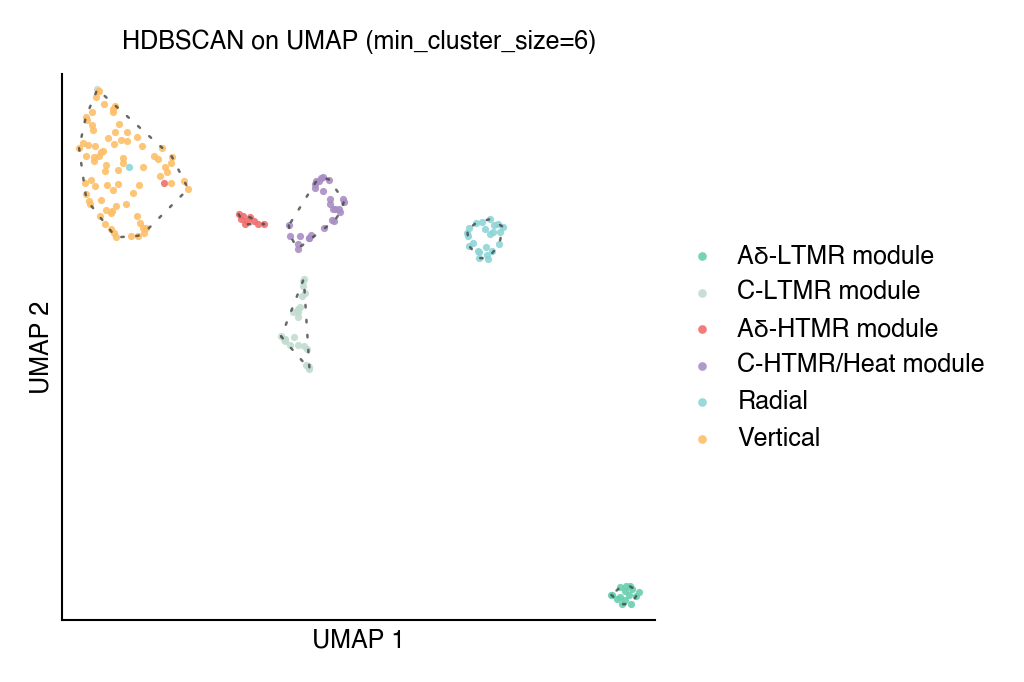

,UMAP1,UMAP2,original_label,display_group,hdbscan_cluster,hdbscan_probability
root_id,,,,,,
720575940907584340,14.926209,-5.219783,adltmr_module,Aδ-LTMR module,0,1.000000
720575940880839442,14.327423,-5.556291,adltmr_module,Aδ-LTMR module,0,0.980893
720575940883729656,15.086834,-5.438572,adltmr_module,Aδ-LTMR module,0,0.837255
720575940948987670,14.799005,-5.407074,adltmr_module,Aδ-LTMR module,0,1.000000
720575940890900801,15.182483,-5.316289,adltmr_module,Aδ-LTMR module,0,0.725836


In [21]:
# ============================================================
# HDBSCAN on the existing UMAP embedding
#
# Required objects from the previous UMAP cell:
#   embedding : DataFrame with columns UMAP1 and UMAP2
#   y7        : Series with original labels
#
# v1 and v2 are combined as "Vertical" for visualization
# and six-group comparison.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    v_measure_score,
)

# ------------------------------------------------------------
# Import HDBSCAN
# ------------------------------------------------------------

try:
    import hdbscan
except ImportError as exc:
    raise ImportError(
        "The hdbscan package is not installed.\n"
        "Install it in your cave310 environment with:\n"
        "conda install -c conda-forge hdbscan"
    ) from exc


# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

warnings.filterwarnings(
    "ignore",
    message=r".*force_all_finite.*",
    category=FutureWarning,
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
})


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

MIN_CLUSTER_SIZE = 6
MIN_SAMPLES = None

# "eom" generally gives broader, more stable clusters.
# Change to "leaf" for smaller, finer clusters.
CLUSTER_SELECTION_METHOD = "eom"

FIG_SIZE_CM = (9.0, 6.0)
POINT_SIZE = 3
POINT_ALPHA = 0.9

SAVE_SVG_PATH = "figure2d_umap_hdbscan_outlined.svg"
# Example:
# SAVE_SVG_PATH = (
#     "figure2d_umap_hdbscan.svg"
# )


# ------------------------------------------------------------
# Validate and align inputs
# ------------------------------------------------------------

if "embedding" not in globals():
    raise NameError(
        "embedding does not exist. Run the UMAP cell first."
    )

if "y7" not in globals():
    raise NameError(
        "y7 does not exist. Run the combined-feature cell first."
    )

required_embedding_columns = {"UMAP1", "UMAP2"}

if not required_embedding_columns.issubset(embedding.columns):
    raise ValueError(
        "embedding must contain UMAP1 and UMAP2 columns."
    )

embedding_hdb = embedding.loc[:, ["UMAP1", "UMAP2"]].copy()
y7_hdb = y7.loc[embedding_hdb.index].copy()


# ------------------------------------------------------------
# Merge v1 and v2 for display/comparison only
# ------------------------------------------------------------

DISPLAY_NAME_MAP = {
    "adltmr_module": "Aδ-LTMR module",
    "cltmr_module": "C-LTMR module",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "r": "Radial",
    "v1": "Vertical",
    "v2": "Vertical",
}

COLOR_MAP = {

    "Aδ-HTMR module":     "#f16e6e",  # was #d48b8b
    "C-HTMR/Heat module": "#a98ec4",  # was #a99ab8
    "C-LTMR module":      "#c2ddd0",  # was #c8d7d0
    "Aδ-LTMR module":     "#68cfae",  # was #7fb8a6
    "Radial":             "#8dd5d9",  # was #9ec6c8
    "Vertical":           "#fdbf68",  # was #efe6b0
    "Noise":              "#b0b0b0",  # unchanged
}

DISPLAY_ORDER = [
    "Aδ-LTMR module",
    "C-LTMR module",
    "Aδ-HTMR module",
    "C-HTMR/Heat module",
    "Radial",
    "Vertical",
    "Noise",
]

y6_display = y7_hdb.map(DISPLAY_NAME_MAP)

if y6_display.isna().any():
    bad_labels = sorted(
        y7_hdb.loc[y6_display.isna()].unique()
    )
    raise ValueError(
        f"Unexpected labels in y7: {bad_labels}"
    )


# ------------------------------------------------------------
# Run HDBSCAN on the two-dimensional UMAP coordinates
# ------------------------------------------------------------

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=int(MIN_CLUSTER_SIZE),
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method=CLUSTER_SELECTION_METHOD,
    prediction_data=True,
)

cluster_array = hdbscan_model.fit_predict(
    embedding_hdb[["UMAP1", "UMAP2"]].to_numpy()
)

cluster_probability = hdbscan_model.probabilities_

hdbscan_clusters = pd.Series(
    cluster_array,
    index=embedding_hdb.index,
    name="hdbscan_cluster",
)

hdbscan_probability = pd.Series(
    cluster_probability,
    index=embedding_hdb.index,
    name="hdbscan_probability",
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

cluster_sizes = (
    hdbscan_clusters
    .value_counts()
    .sort_index()
)

number_of_clusters = (
    hdbscan_clusters.loc[
        hdbscan_clusters != -1
    ].nunique()
)

number_of_noise = int(
    hdbscan_clusters.eq(-1).sum()
)

print("HDBSCAN summary")
print("----------------")
print(f"Neurons: {len(hdbscan_clusters)}")
print(f"Clusters, excluding noise: {number_of_clusters}")
print(
    f"Noise: {number_of_noise} / {len(hdbscan_clusters)} "
    f"({number_of_noise / len(hdbscan_clusters):.1%})"
)

print("\nCluster sizes:")
print(cluster_sizes)


# ------------------------------------------------------------
# Compare unsupervised clusters with known labels
# ------------------------------------------------------------

def clustering_scores(
    known_labels: pd.Series,
    predicted_clusters: pd.Series,
):
    return {
        "ARI": adjusted_rand_score(
            known_labels,
            predicted_clusters,
        ),
        "NMI": normalized_mutual_info_score(
            known_labels,
            predicted_clusters,
        ),
        "V-measure": v_measure_score(
            known_labels,
            predicted_clusters,
        ),
    }


# Six displayed biological groups, including noise
scores_all = clustering_scores(
    y6_display,
    hdbscan_clusters,
)

print("\nAgreement with six displayed groups, including noise:")
for metric_name, metric_value in scores_all.items():
    print(f"{metric_name}: {metric_value:.3f}")


# Scores excluding noise
non_noise_mask = hdbscan_clusters.ne(-1)

if (
    non_noise_mask.sum() > 0
    and hdbscan_clusters.loc[non_noise_mask].nunique() >= 2
):
    scores_no_noise = clustering_scores(
        y6_display.loc[non_noise_mask],
        hdbscan_clusters.loc[non_noise_mask],
    )

    print("\nAgreement excluding noise:")
    for metric_name, metric_value in scores_no_noise.items():
        print(f"{metric_name}: {metric_value:.3f}")

    print(
        f"Retained: {non_noise_mask.sum()} / "
        f"{len(non_noise_mask)} neurons"
    )


# ------------------------------------------------------------
# Cluster composition table
# ------------------------------------------------------------

cluster_composition = pd.crosstab(
    hdbscan_clusters,
    y6_display,
)

cluster_composition = cluster_composition.reindex(
    columns=[
        name
        for name in DISPLAY_ORDER
        if name != "Noise"
    ],
    fill_value=0,
)

print("\nCluster composition, counts:")
display(cluster_composition)

cluster_composition_fraction = (
    cluster_composition
    .div(
        cluster_composition.sum(axis=1).replace(0, np.nan),
        axis=0,
    )
    .fillna(0.0)
)

print("\nCluster composition, row fractions:")
display(cluster_composition_fraction.round(3))


# ------------------------------------------------------------
# Majority biological identity of each HDBSCAN cluster
# ------------------------------------------------------------

cluster_majority_label = (
    pd.DataFrame({
        "cluster": hdbscan_clusters,
        "known_group": y6_display,
    })
    .query("cluster != -1")
    .groupby("cluster")["known_group"]
    .agg(lambda values: values.value_counts().idxmax())
)

print("\nMajority known group for each HDBSCAN cluster:")
display(
    cluster_majority_label.rename(
        "majority_known_group"
    ).to_frame()
)


# ------------------------------------------------------------
# Convex-hull helper
# ------------------------------------------------------------

def convex_hull_indices(points: np.ndarray):
    """
    Andrew monotone-chain convex hull.

    Returns indices referring to the original points array.
    """

    if len(points) < 3:
        return np.arange(len(points))

    order = np.lexsort(
        (points[:, 1], points[:, 0])
    )

    sorted_points = points[order]

    def cross(origin, point_a, point_b):
        return (
            (point_a[0] - origin[0])
            * (point_b[1] - origin[1])
            - (point_a[1] - origin[1])
            * (point_b[0] - origin[0])
        )

    lower = []

    for index, point in enumerate(sorted_points):
        while (
            len(lower) >= 2
            and cross(
                sorted_points[lower[-2]],
                sorted_points[lower[-1]],
                point,
            ) <= 0
        ):
            lower.pop()

        lower.append(index)

    upper = []

    for reverse_index, point in enumerate(
        sorted_points[::-1]
    ):
        sorted_index = (
            len(sorted_points)
            - 1
            - reverse_index
        )

        while (
            len(upper) >= 2
            and cross(
                sorted_points[upper[-2]],
                sorted_points[upper[-1]],
                point,
            ) <= 0
        ):
            upper.pop()

        upper.append(sorted_index)

    hull_sorted_indices = (
        lower[:-1] + upper[:-1]
    )

    return order[hull_sorted_indices]


def cm_to_inches(
    width_cm: float,
    height_cm: float,
):
    return (
        width_cm / 2.54,
        height_cm / 2.54,
    )


# ------------------------------------------------------------
# Plot known groups, with HDBSCAN cluster outlines
# Show UMAP 1 and UMAP 2 axes
# ------------------------------------------------------------

def plot_hdbscan_outlines(
    embedding_df: pd.DataFrame,
    cluster_labels: pd.Series,
    known_display_labels: pd.Series,
    *,
    title="",
    figure_size_cm=(7.0, 4.0),
    point_size=5,
    point_alpha=0.9,
    hull_linewidth=0.6,
    hull_linestyle=(0, (1.0, 5.0)),
    hull_color="#444444",
    hull_alpha=0.8,
    save_svg_path=None,
):
    plot_labels = known_display_labels.copy()

    # Display HDBSCAN noise as gray
    plot_labels.loc[
        cluster_labels.eq(-1)
    ] = "Noise"

    fig, ax = plt.subplots(
        figsize=cm_to_inches(
            *figure_size_cm
        ),
        dpi=300,
    )

    # Plot points colored by known biological group
    for group_name in DISPLAY_ORDER:
        group_mask = plot_labels.eq(
            group_name
        )

        if not group_mask.any():
            continue

        group_ids = plot_labels.index[
            group_mask
        ]

        ax.scatter(
            embedding_df.loc[
                group_ids,
                "UMAP1",
            ],
            embedding_df.loc[
                group_ids,
                "UMAP2",
            ],
            s=point_size,
            alpha=point_alpha,
            c=COLOR_MAP[group_name],
            label=group_name,
            linewidths=0,
            zorder=2,
        )

    # Outline each non-noise HDBSCAN cluster
    non_noise_clusters = sorted(
        cluster_labels.loc[
            cluster_labels != -1
        ].unique()
    )

    for cluster_id in non_noise_clusters:
        cluster_ids = cluster_labels.index[
            cluster_labels.eq(cluster_id)
        ]

        points = embedding_df.loc[
            cluster_ids,
            ["UMAP1", "UMAP2"],
        ].to_numpy()

        if len(points) < 3:
            continue

        hull_indices = convex_hull_indices(
            points
        )

        closed_indices = np.r_[
            hull_indices,
            hull_indices[0],
        ]

        ax.plot(
            points[closed_indices, 0],
            points[closed_indices, 1],
            linestyle=hull_linestyle,
            linewidth=hull_linewidth,
            color=hull_color,
            alpha=hull_alpha,
            dash_capstyle="round",
            zorder=3,
        )

    # --------------------------------------------------------
    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_title(title)

    ax.set_xlabel(
        "UMAP 1",
        labelpad=2,
    )

    ax.set_ylabel(
        "UMAP 2",
        labelpad=2,
    )

    # Remove numerical ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # Keep only left and bottom axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)

    ax.grid(False)
    ax.margins(0.03)

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    box = ax.get_position()

    ax.set_position([
        box.x0,
        box.y0,
        box.width * 0.72,
        box.height,
    ])

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        borderaxespad=0.0,
        handletextpad=0.4,
        markerscale=1.2,
    )

    # --------------------------------------------------------
    # Optional saving
    # --------------------------------------------------------

    if save_svg_path is not None:
        fig.savefig(
            str(save_svg_path),
            format="svg",
            bbox_inches="tight",
            transparent=False,
        )

        print(f"Saved: {save_svg_path}")

    plt.show()

    return fig, ax

fig_hdbscan, ax_hdbscan = plot_hdbscan_outlines(
    embedding_df=embedding_hdb,
    cluster_labels=hdbscan_clusters,
    known_display_labels=y6_display,
    title=(
        f"HDBSCAN on UMAP "
        f"(min_cluster_size={MIN_CLUSTER_SIZE})"
    ),
    figure_size_cm=FIG_SIZE_CM,
    point_size=POINT_SIZE,
    point_alpha=POINT_ALPHA,
    save_svg_path=SAVE_SVG_PATH,
)


# ------------------------------------------------------------
# Combined result dataframe for inspection
# ------------------------------------------------------------

hdbscan_result = embedding_hdb.copy()

hdbscan_result["original_label"] = y7_hdb
hdbscan_result["display_group"] = y6_display
hdbscan_result["hdbscan_cluster"] = hdbscan_clusters
hdbscan_result["hdbscan_probability"] = hdbscan_probability

display(
    hdbscan_result.head()
)

Morphology features: 13
Connectivity features: 20
Total features plotted: 33
Saved: figureS2b_zscore_feature_heatmap.svg


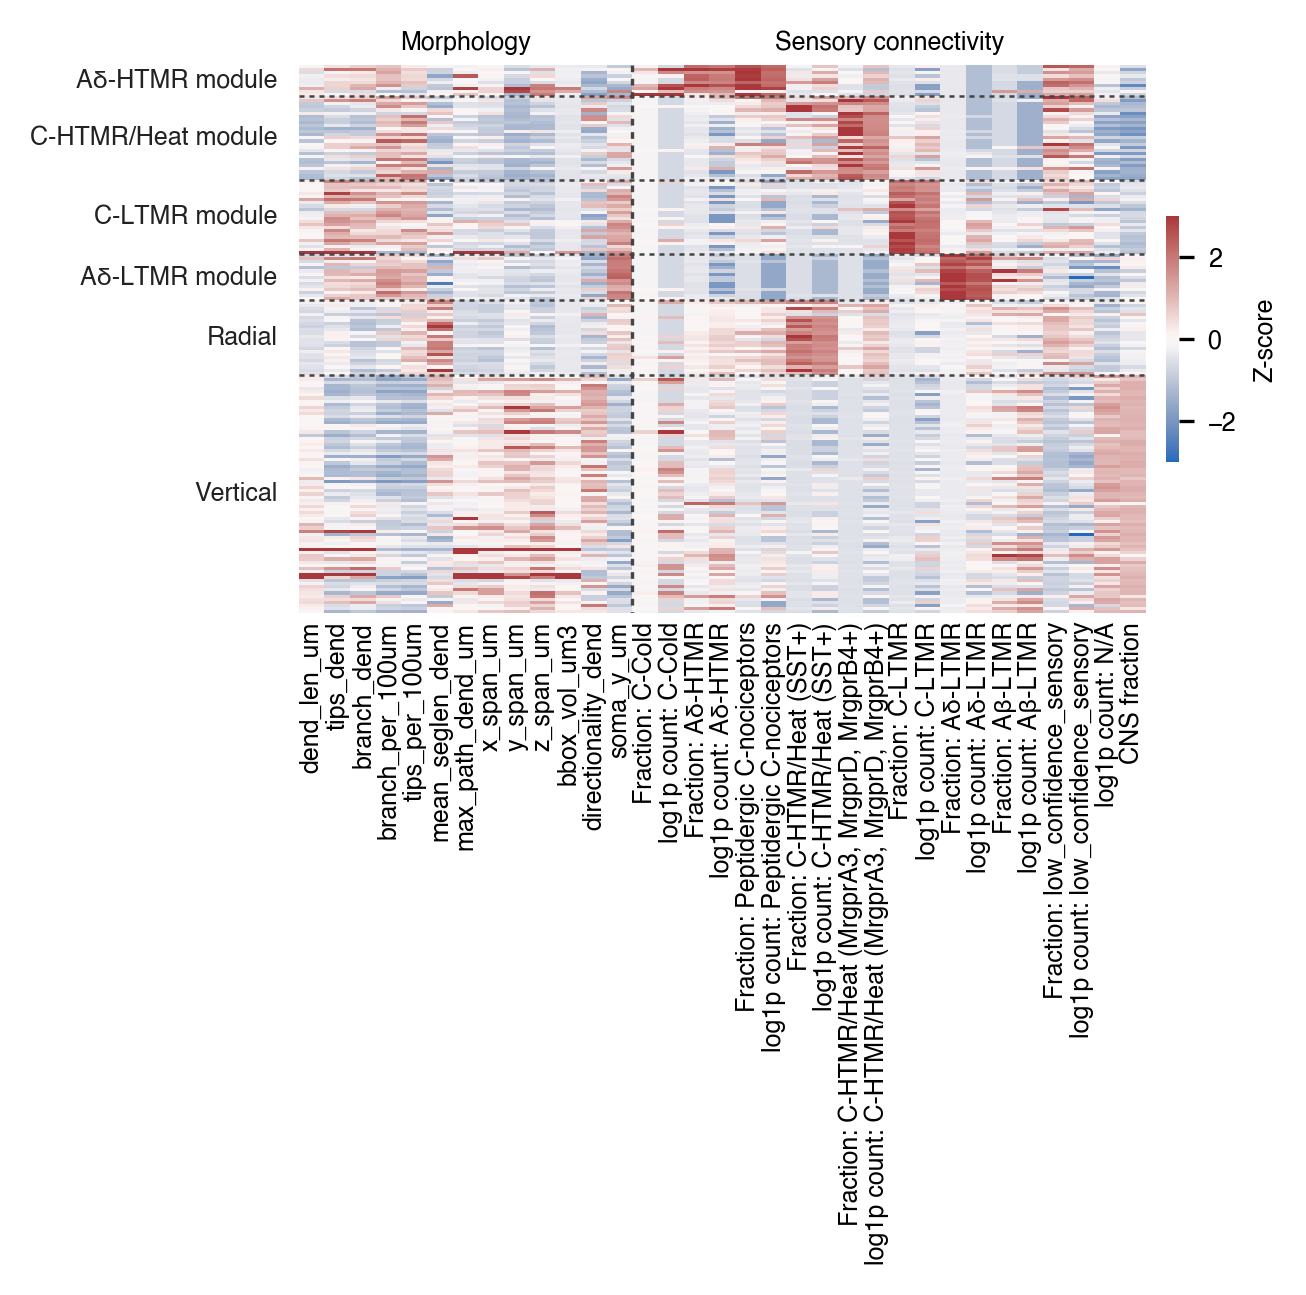

In [22]:
# ============================================================
# Z-score heatmap of the features actually used in X
#
# Rows:
#   neurons, sorted by six-class biological label
#
# Columns:
#   morphology features first
#   connectivity / sensory-input features second
#
# Required objects:
#   X  : DataFrame used for classification / UMAP
#   y7 : original seven-class label Series
# ============================================================

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.transforms import blended_transform_factory
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# Style
# ------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Helvetica",
        "Arial",
        "DejaVu Sans",
    ],
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
})


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

CLIP_ZSCORE = 3.0

FIG_SIZE_CM = (
    12.0,
    8.0,
)

SAVE_SVG_PATH = (
    "figureS2b_zscore_feature_heatmap.svg"
)

# Set to None to disable saving:
# SAVE_SVG_PATH = None


# ------------------------------------------------------------
# Six-class label display
# ------------------------------------------------------------

DISPLAY_NAME_MAP = {
    "adltmr_module": "Aδ-LTMR module",
    "cltmr_module": "C-LTMR module",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "r": "Radial",
    "v1": "Vertical",
    "v2": "Vertical",
}

GROUP_ORDER = [
    "Aδ-HTMR module",
    "C-HTMR/Heat module",
    "C-LTMR module",
    "Aδ-LTMR module",
    "Radial",
    "Vertical",
]


# ------------------------------------------------------------
# Preferred morphology order
#
# Only features that remain in X will be plotted.
# Therefore, dropped features such as bbox_vol_um3 or
# path_vs_straight will automatically be excluded.
# ------------------------------------------------------------

MORPHOLOGY_ORDER = [
    "dend_len_um",
    "tips_dend",
    "branch_dend",
    "branch_per_100um",
    "tips_per_100um",
    "mean_seglen_dend",
    "max_path_dend_um",
    "x_span_um",
    "y_span_um",
    "z_span_um",
    "bbox_vol_um3",
    "directionality_dend",
    "path_vs_straight",
    "soma_y_um",
]


# ------------------------------------------------------------
# Preferred sensory/connectivity type order
# ------------------------------------------------------------

SENSORY_TYPE_ORDER = [
    "C-Cold",
    "Aδ-HTMR",
    "C-Heat",
    "C-HTMR",
    "C-HTMR-Non-peptidergic",
    "C-LTMR",
    "Aδ-LTMR",
    "Aβ-LTMR",
    "low_confidence_sensory",
    "N/A",
]

SENSORY_RENAME = {
    "C-HTMR": "C-HTMR/Heat (SST+)",
    "C-HTMR-Non-peptidergic":
        "C-HTMR/Heat (MrgprA3, MrgprD, MrgprB4+)",
    "C-Heat": "Peptidergic C-nociceptors",
}


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def cm_to_inches(
    width_cm,
    height_cm,
):
    return (
        width_cm / 2.54,
        height_cm / 2.54,
    )


def is_connectivity_feature(
    feature_name,
):
    """
    Identify sensory-input / connectivity features.
    """

    return (
        feature_name.startswith("sens_frac__")
        or feature_name.startswith("sens_log1p__")
        or feature_name == "cns_fraction"
    )


def display_feature_name(
    feature_name,
):
    """
    Rename feature labels for display only.
    The underlying X column names remain unchanged.
    """

    if feature_name.startswith("sens_frac__"):
        sensory_type = feature_name.split(
            "sens_frac__",
            1,
        )[1]

        sensory_type = SENSORY_RENAME.get(
            sensory_type,
            sensory_type,
        )

        return f"Fraction: {sensory_type}"

    if feature_name.startswith("sens_log1p__"):
        sensory_type = feature_name.split(
            "sens_log1p__",
            1,
        )[1]

        sensory_type = SENSORY_RENAME.get(
            sensory_type,
            sensory_type,
        )

        return f"log1p count: {sensory_type}"

    if feature_name == "cns_fraction":
        return "CNS fraction"

    return feature_name


def contiguous_blocks(
    labels,
):
    """
    Return contiguous label blocks as:

        (label, first_row, last_row)
    """

    values = labels.to_numpy()

    if len(values) == 0:
        return []

    blocks = []
    start = 0

    for i in range(
        1,
        len(values),
    ):
        if values[i] != values[i - 1]:
            blocks.append(
                (
                    values[start],
                    start,
                    i - 1,
                )
            )
            start = i

    blocks.append(
        (
            values[start],
            start,
            len(values) - 1,
        )
    )

    return blocks


def order_connectivity_features(
    columns,
):
    """
    Order frac and log1p features next to each other
    for each sensory type.
    """

    ordered = []

    for sensory_type in SENSORY_TYPE_ORDER:

        frac_name = (
            f"sens_frac__{sensory_type}"
        )

        count_name = (
            f"sens_log1p__{sensory_type}"
        )

        if frac_name in columns:
            ordered.append(frac_name)

        if count_name in columns:
            ordered.append(count_name)

    if "cns_fraction" in columns:
        ordered.append("cns_fraction")

    # Append any connectivity columns not included above
    ordered += [
        column
        for column in columns
        if column not in ordered
    ]

    return ordered


# ------------------------------------------------------------
# Validate and align X and labels
# ------------------------------------------------------------

if "X" not in globals():
    raise NameError(
        "X does not exist. Run the combined-feature cell first."
    )

if "y7" not in globals():
    raise NameError(
        "y7 does not exist. Run the label-building cell first."
    )

if not isinstance(
    X,
    pd.DataFrame,
):
    raise TypeError(
        "X must be a pandas DataFrame so feature names are available."
    )

common_ids = X.index.intersection(
    y7.index
)

if len(common_ids) == 0:
    raise ValueError(
        "X and y7 do not contain matching neuron IDs."
    )

X_heatmap = X.loc[
    common_ids
].copy()

y7_heatmap = y7.loc[
    common_ids
].copy()


# ------------------------------------------------------------
# Create six-class labels
# ------------------------------------------------------------

y6_display = y7_heatmap.map(
    DISPLAY_NAME_MAP
)

if y6_display.isna().any():

    unexpected_labels = sorted(
        y7_heatmap.loc[
            y6_display.isna()
        ].astype(str).unique()
    )

    raise ValueError(
        "Unexpected labels in y7: "
        f"{unexpected_labels}"
    )


# ------------------------------------------------------------
# Separate morphology and connectivity features
#
# Critically, this starts from X.columns, so only the features
# actually used in classification and UMAP are included.
# ------------------------------------------------------------

used_features = list(
    X_heatmap.columns
)

morphology_features_present = [
    feature
    for feature in MORPHOLOGY_ORDER
    if feature in used_features
]

# Include any remaining non-connectivity feature that was not
# explicitly listed in MORPHOLOGY_ORDER
extra_morphology_features = [
    feature
    for feature in used_features
    if (
        not is_connectivity_feature(feature)
        and feature
        not in morphology_features_present
    )
]

morphology_features = (
    morphology_features_present
    + extra_morphology_features
)

connectivity_features_raw = [
    feature
    for feature in used_features
    if is_connectivity_feature(feature)
]

connectivity_features = (
    order_connectivity_features(
        connectivity_features_raw
    )
)

feature_order = (
    morphology_features
    + connectivity_features
)

print(
    f"Morphology features: "
    f"{len(morphology_features)}"
)

print(
    f"Connectivity features: "
    f"{len(connectivity_features)}"
)

print(
    f"Total features plotted: "
    f"{len(feature_order)}"
)


# ------------------------------------------------------------
# Z-score each feature across neurons
#
# This produces the same standardized values used by a
# StandardScaler-based analysis, before clipping for display.
# ------------------------------------------------------------

scaler = StandardScaler()

Z = pd.DataFrame(
    scaler.fit_transform(
        X_heatmap.loc[
            :,
            feature_order,
        ]
    ),
    index=X_heatmap.index,
    columns=feature_order,
)

Z = Z.clip(
    -CLIP_ZSCORE,
    CLIP_ZSCORE,
)


# ------------------------------------------------------------
# Sort neurons by six-class label
#
# Within each class, preserve the current X row order.
# ------------------------------------------------------------

label_rank = {
    label: rank
    for rank, label in enumerate(
        GROUP_ORDER
    )
}

sorting_table = pd.DataFrame(
    {
        "group": y6_display,
        "original_order": np.arange(
            len(y6_display)
        ),
    },
    index=y6_display.index,
)

sorting_table["group_rank"] = (
    sorting_table["group"]
    .map(label_rank)
    .fillna(len(GROUP_ORDER))
)

row_order = (
    sorting_table
    .sort_values(
        [
            "group_rank",
            "original_order",
        ]
    )
    .index
)

Z_plot = Z.loc[
    row_order,
    feature_order,
]

labels_plot = y6_display.loc[
    row_order
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=cm_to_inches(
        *FIG_SIZE_CM
    ),
    dpi=300,
)

heatmap = sns.heatmap(
    Z_plot,
    ax=ax,
    cmap="vlag",
    center=0,
    vmin=-CLIP_ZSCORE,
    vmax=CLIP_ZSCORE,
    xticklabels=[
        display_feature_name(feature)
        for feature in feature_order
    ],
    yticklabels=False,
    cbar=True,
    cbar_kws={
        "label": "Z-score",
        "shrink": 0.45,
        "pad": 0.02,
    },
    rasterized=True,
)


# ------------------------------------------------------------
# Format feature labels
# ------------------------------------------------------------

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    ha="center",
    va="top",
    fontfamily="Helvetica",
    fontsize=6,
)

ax.tick_params(
    axis="x",
    length=0,
    pad=2,
)

ax.tick_params(
    axis="y",
    length=0,
)

ax.set_xlabel("")
ax.set_ylabel("")


# ------------------------------------------------------------
# Horizontal separators between biological groups
# ------------------------------------------------------------

label_values = labels_plot.to_numpy()

group_change_rows = (
    np.where(
        label_values[1:]
        != label_values[:-1]
    )[0]
    + 1
)

for boundary in group_change_rows:
    ax.hlines(
        y=boundary,
        xmin=0,
        xmax=len(feature_order),
        colors="#444444",
        linestyles=(0, (2, 2)),
        linewidth=0.6,
        zorder=5,
    )


# ------------------------------------------------------------
# Vertical separator between morphology and connectivity
# ------------------------------------------------------------

n_morphology = len(
    morphology_features
)

if (
    n_morphology > 0
    and len(connectivity_features) > 0
):
    ax.vlines(
        x=n_morphology,
        ymin=0,
        ymax=Z_plot.shape[0],
        colors="#444444",
        linestyles=(0, (2, 2)),
        linewidth=0.8,
        zorder=6,
    )


# ------------------------------------------------------------
# Group labels along the left side
# ------------------------------------------------------------

row_label_transform = (
    blended_transform_factory(
        ax.transAxes,
        ax.transData,
    )
)

for (
    group_name,
    first_row,
    last_row,
) in contiguous_blocks(
    labels_plot
):

    center_y = (
        first_row
        + last_row
        + 1
    ) / 2

    ax.text(
        -0.025,
        center_y,
        group_name,
        transform=row_label_transform,
        ha="right",
        va="center",
        fontsize=6,
        fontweight="bold",
        color="#222222",
        clip_on=False,
    )


# ------------------------------------------------------------
# Label morphology and connectivity blocks above columns
# ------------------------------------------------------------

column_label_transform = (
    blended_transform_factory(
        ax.transData,
        ax.transAxes,
    )
)

if len(morphology_features) > 0:

    morphology_center = (
        len(morphology_features)
        / 2
    )

    ax.text(
        morphology_center,
        1.02,
        "Morphology",
        transform=column_label_transform,
        ha="center",
        va="bottom",
        fontsize=6,
        fontweight="bold",
        clip_on=False,
    )

if len(connectivity_features) > 0:

    connectivity_center = (
        len(morphology_features)
        + len(connectivity_features) / 2
    )

    ax.text(
        connectivity_center,
        1.02,
        "Sensory connectivity",
        transform=column_label_transform,
        ha="center",
        va="bottom",
        fontsize=6,
        fontweight="bold",
        clip_on=False,
    )


# ------------------------------------------------------------
# Clean heatmap frame
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)


# ------------------------------------------------------------
# Layout and saving
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.22,
    right=0.94,
    top=0.91,
    bottom=0.33,
)

if SAVE_SVG_PATH is not None:
    fig.savefig(
        SAVE_SVG_PATH,
        format="svg",
        bbox_inches="tight",
        transparent=False,
    )

    print(
        f"Saved: {SAVE_SVG_PATH}"
    )

plt.show()